# <center> De-Anonymizing and $k$-Anonymizing Individuals using Subject-Object Knowledge Relations </center>


                    PAPER ANALYSIS SUITE
        De-Anonymizing and k-Anonymizing Individuals
               using Subject-Object Relations

[1/4] Generating Table 1 (De-Anonymization Example)...

TABLE 1: Resource Comparison (Student Example)
                        Method  New Nodes in V2'  Edges Added  Total Edges in G' (Initial=6)
                         Naive                 4            4                             10
Our Heuristic (DeAnonMinGraph)                 0            3                              9
          Optimal (bruteforce)                 0            3                              9
Initial edges: 6


[2/4] Generating Figure 1 (De-Anonymization Example Plot)...


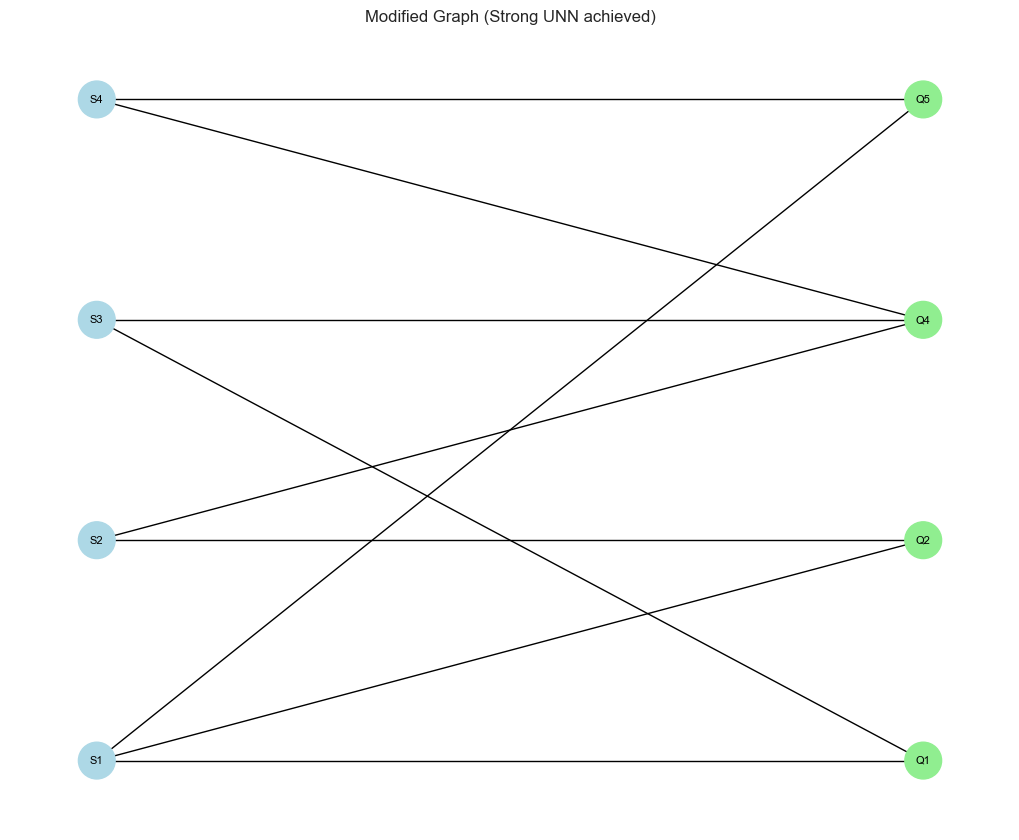

  De-Anonymization visualization saved as '1.png'


[3/4] Generating Table 2 (Comparative Performance for K-Anon)...

TABLE 2: Comparative Performance
Dataset: 51 users, 1287 resources, 2536 initial edges (Synthetic)
Target: k=3 anonymity

Running Our KAnonHomogenize method (Smallest-First)...
Running k-Degree Anonymization (basic implemented version)...
                                          Method        Edges Added Nodes Added Runtime (s) Utility*                                                        Source
                    Our Method (KAnonHomogenize)               4724           0       9.407    0.000                                          Computed (this code)
            k-Degree (basic implemented version)                960           0       5.895    0.267                                          Computed (this code)
                    k-Degree [Liu & Terzi, 2008] N/A (not reported)         N/A         N/A      N/A                Original paper – metrics not directly 

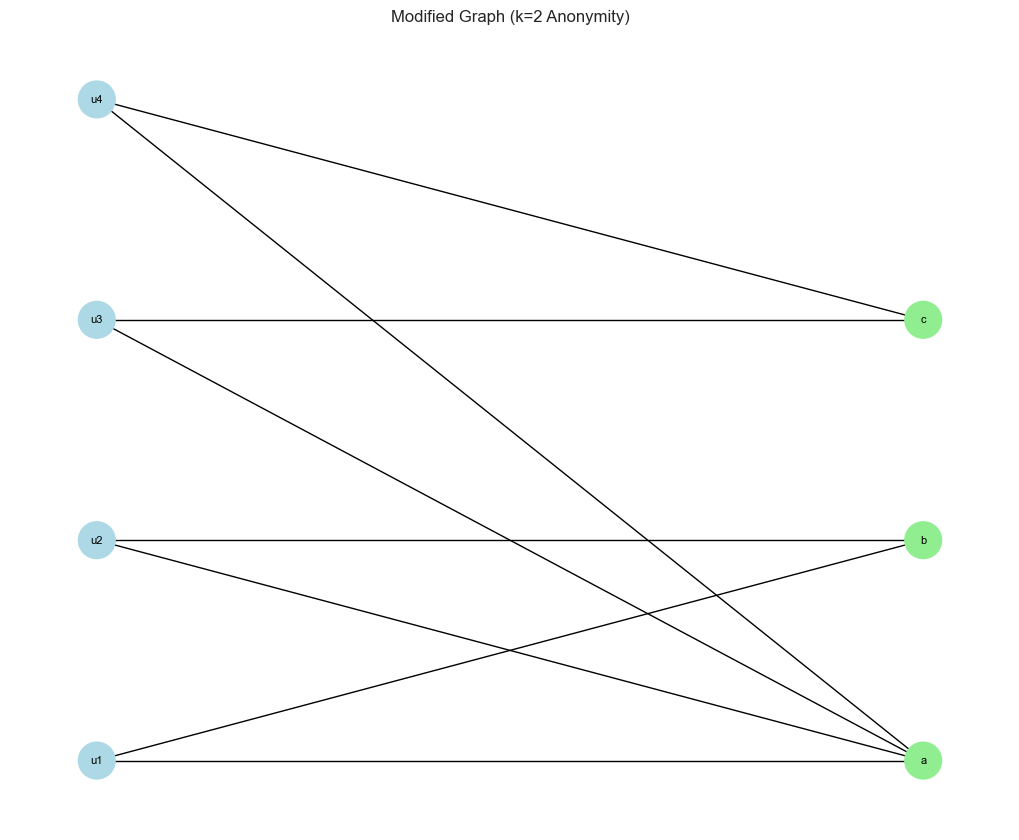

  KAnonHomogenize illustrative plot saved as '2.png'


All analyses completed successfully!

Generated files:
  Tables:
    • table1_resource_comparison.csv
    • table2_comparative_performance.csv
    • table3_heuristic_performance.csv
  Figures:
    • 1.png (De-Anonymization Example)
    • 2.png (KAnonHomogenize Example)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
import time
from itertools import combinations
import seaborn as sns
from typing import Dict, Set, List, Tuple
import random
import warnings
from openpyxl import load_workbook # Added for data loading

# Suppress specific warnings - usually good for clean console output in notebooks
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Configure matplotlib to use a font that supports subscripts
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['mathtext.fontset'] = 'dejavusans'

# ==============================================================================
# CORE ALGORITHMS
# ==============================================================================

# --- Helper for KL-Divergence Calculation ---
def compute_kl_divergence(dist1, dist2):
    """
    Compute Kullback-Leibler (KL) divergence between two degree distributions.
    Used as part of the utility metric (1 - KL).
    """
    # Ensure distributions are non-empty and non-negative
    if not dist1 or not dist2:
        return 1.0 # Max divergence if one is empty

    # Convert to histograms
    # Find min/max degree across both distributions for consistent binning
    min_deg = min(min(dist1), min(dist2))
    max_deg = max(max(dist1), max(dist2))
    bins = np.arange(min_deg, max_deg + 2) # +2 to include max_deg in a bin

    hist1, _ = np.histogram(dist1, bins=bins, density=True)
    hist2, _ = np.histogram(dist2, bins=bins, density=True)

    # Add a small epsilon to avoid log(0)
    epsilon = 1e-10
    hist1 = hist1 + epsilon
    hist2 = hist2 + epsilon

    # Normalize to sum to 1
    hist1 = hist1 / hist1.sum()
    hist2 = hist2 / hist2.sum()

    # Calculate KL divergence
    kl = np.sum(hist1 * np.log(hist1 / hist2))
    return min(kl, 1.0) # Cap KL at 1.0 for utility calculations

# --- Graph Creation ---
def create_bipartite_graph(student_to_questions: Dict[str, Set[str]]):
    """Create bipartite graph from student-question mapping"""
    G = nx.Graph()
    students = list(student_to_questions.keys())
    # Extract all unique questions from all student sets
    questions = list(set().union(*student_to_questions.values()))

    # Add nodes to graph, specifying their bipartite partition (0 for students, 1 for questions)
    G.add_nodes_from(students, bipartite=0)
    G.add_nodes_from(questions, bipartite=1)

    # Add edges
    for student, qs in student_to_questions.items():
        for q in qs:
            G.add_edge(student, q)
    return G, students, questions

# --- Check Strong UNN Property ---
def check_strong_unn(G, students):
    """
    Check if the strong UNN property is satisfied for all pairs of students.
    Returns (True, None) if satisfied, else (False, (u, v)) for a violating pair.
    """
    for i, u in enumerate(students):
        for v in students[i+1:]: # Compare each pair only once
            N_u = set(G.neighbors(u))
            N_v = set(G.neighbors(v))
            # Check for subset relationships (N_u subset of N_v OR N_v subset of N_u)
            if N_u.issubset(N_v) or N_v.issubset(N_u):
                return False, (u, v)
    return True, None

# --- Naive De-Anonymization Baseline ---
def naive_deanonymization(student_to_questions):
    """
    Naive approach: adds one unique dummy node (question) for each student.
    Used as a baseline for DeAnonMinGraph.
    """
    result = {s: q.copy() for s, q in student_to_questions.items()}
    # Determine the highest existing question ID to generate new unique ones
    max_q_id = max((int(q[1:]) for q in set().union(*result.values()) if q.startswith('Q') and q[1:].isdigit()), default=0)

    nodes_added = 0
    edges_added = 0
    
    # Assign a unique new question to each student
    for i, student in enumerate(result.keys()):
        new_q = f"Q{max_q_id + i + 1}"
        result[student].add(new_q) # Add to student's questions
        nodes_added += 1 # Count the new question node
        edges_added += 1 # Count the new edge

    return result, nodes_added, edges_added

# --- DeAnonMinGraph Algorithm (Algorithm 1 in Paper) ---
def deanon_min_graph(student_to_questions, max_iterations=1000):
    """
    DeAnonMinGraph algorithm with a min-degree heuristic to achieve strong UNN.
    Prioritizes adding edges to existing items.
    """
    # Deep copy the initial mapping to preserve original
    result = {s: q.copy() for s, q in student_to_questions.items()}
    
    students = list(result.keys())
    
    initial_questions_pool = list(set().union(*student_to_questions.values()))
    current_all_questions = initial_questions_pool[:] # Track V2' dynamically
    max_q_id = max((int(q[1:]) for q in current_all_questions if q.startswith('Q') and q[1:].isdigit()), default=0)


    nodes_added_count = 0
    edges_added_count = 0
    
    iteration = 0
    while iteration < max_iterations:
        iteration += 1
        
        # Recreate graph from the current 'result' state for fresh checks and degrees
        G, _, _ = create_bipartite_graph(result) 
        is_unn, violating_pair = check_strong_unn(G, students)
        
        if is_unn:
            break # Strong UNN property satisfied for all pairs

        u, v = violating_pair
        
        modification_made_in_iteration = False

        # Priority 1: Resolve subset violations using existing items
        # Case 1: N_u is a subset of N_v
        G_current_iteration, _, _ = create_bipartite_graph(result) # Fresh graph for current iteration
        N_u = set(G_current_iteration.neighbors(u))
        N_v = set(G_current_iteration.neighbors(v))

        if N_u.issubset(N_v):
            # Heuristic: Choose the least-connected item not in N_v to add to u
            candidates = [q_item for q_item in G_current_iteration.nodes() 
                          if G_current_iteration.nodes[q_item].get('bipartite') == 1 and q_item not in N_v]
            if candidates:
                q_to_add = min(candidates, key=lambda x: G_current_iteration.degree(x))
                result[u].add(q_to_add)
                edges_added_count += 1
                modification_made_in_iteration = True
                
        # Case 2: N_v is a subset of N_u (re-evaluate neighborhoods after potential modification of N_u)
        G_recheck, _, _ = create_bipartite_graph(result) # Recreate graph to get updated N_u (if modified)
        N_u_recheck = set(G_recheck.neighbors(u))
        N_v_recheck = set(G_recheck.neighbors(v)) # Also get latest N_v

        if N_v_recheck.issubset(N_u_recheck):
            # Heuristic: Choose the least-connected item not in N_u_recheck to add to v
            candidates = [q_item for q_item in G_recheck.nodes() 
                          if G_recheck.nodes[q_item].get('bipartite') == 1 and q_item not in N_u_recheck]
            if candidates:
                p_to_add = min(candidates, key=lambda x: G_recheck.degree(x))
                result[v].add(p_to_add)
                edges_added_count += 1
                modification_made_in_iteration = True
                
        # Priority 2: If necessary (no modification made or N_u == N_v still holds), introduce a new item
        # Get latest neighborhoods for final comparison in this iteration
        G_final_check, _, _ = create_bipartite_graph(result)
        N_u_final = set(G_final_check.neighbors(u))
        N_v_final = set(G_final_check.neighbors(v))

        if not modification_made_in_iteration or N_u_final == N_v_final:
            max_q_id += 1
            new_q_node = f"Q{max_q_id}"
            
            result[u].add(new_q_node) # Connect to 'u' to break equality/subset
            
            nodes_added_count += 1
            edges_added_count += 1
            
            # Ensure this new_q_node is added to the general pool of questions
            if new_q_node not in current_all_questions:
                current_all_questions.append(new_q_node)

    return result, nodes_added_count, edges_added_count

# --- Optimal Strong UNN (ILP/Bruteforce for small graphs) ---
# Renamed function for clarity
def optimal_strong_unn_bruteforce(student_to_questions):
    """
    Computes an optimal solution for achieving strong UNN using brute-force search
    for a very small number of edge additions. This function is for illustration
    and to derive optimal values for toy examples, not for scalable use.
    """
    students = list(student_to_questions.keys())
    all_questions = list(set().union(*student_to_questions.values()))
    
    # Pre-check if already strong UNN
    G_initial, _, _ = create_bipartite_graph(student_to_questions)
    if check_strong_unn(G_initial, students)[0]:
        return student_to_questions, 0, 0 # Result, nodes added, edges added

    # Collect all possible edges that *could* be added (student, question) pairs that don't currently exist
    possible_edges_to_add_candidates = []
    for s_node in students:
        for q_node in all_questions:
            if q_node not in student_to_questions[s_node]:
                possible_edges_to_add_candidates.append((s_node, q_node))

    min_edges_found = float('inf')
    best_result_map = None
    best_nodes_added = 0 # Currently, this bruteforce only considers adding edges to existing nodes

    # Iterate through adding num_edges (from 1 up to a reasonable max or a hard limit)
    for num_edges_candidate in range(1, len(possible_edges_to_add_candidates) + 1):
        if num_edges_candidate > 10: # Arbitrary small limit for bruteforce practicality
            break
        
        for edges_combination in combinations(possible_edges_to_add_candidates, num_edges_candidate):
            test_student_to_questions = {s: q.copy() for s, q in student_to_questions.items()}
            
            for s_to_add, q_to_add in edges_combination:
                test_student_to_questions[s_to_add].add(q_to_add)
            
            test_G, _, _ = create_bipartite_graph(test_student_to_questions)
            
            if check_strong_unn(test_G, students)[0]:
                if num_edges_candidate < min_edges_found:
                    min_edges_found = num_edges_candidate
                    best_result_map = test_student_to_questions
                    best_nodes_added = 0 # No new nodes introduced by this brute force
                # Since we iterate num_edges_candidate in increasing order, the first valid solution is optimal
                return best_result_map, best_nodes_added, min_edges_found

    return best_result_map, best_nodes_added, min_edges_found # If no solution found within limits, return best so far


# --- KAnonHomogenize Algorithm (Algorithm 2 in Paper) ---
def kAnonHomogenize(user_to_resources: Dict[str, Set[str]], k: int, max_iterations=100):
    """
    KAnonHomogenize algorithm: enforces k-neighbourhood anonymity by homogenizing
    neighborhoods within groups, prioritizing existing resources.
    """
    result = {u: r.copy() for u, r in user_to_resources.items()}
    users = list(result.keys())
    
    current_all_resources = list(set().union(*result.values())) # Dynamically track V2'

    edges_added_count = 0
    edges_removed_count = 0
    nodes_added_count = 0 # For synthetic nodes
    
    iteration = 0
    while iteration < max_iterations:
        iteration += 1
        
        # 1. Compute current neighborhoods and partition users into equivalence classes
        neighborhoods_map = {} # Maps frozenset(nbhd) to list of users
        for u in users:
            # Recreate graph from the current 'result' dict for accurate neighborhood state
            G_current, _, _ = create_bipartite_graph(result) 
            user_neighbors = frozenset([
                n for n in G_current.neighbors(u) 
                if G_current.nodes[n].get("bipartite") == 1
            ])
            neighborhoods_map.setdefault(user_neighbors, []).append(u)
        
        # 2. Identify vulnerable (undersized) groups
        vulnerable_user_groups_list = []
        for nbhd, group_of_users in neighborhoods_map.items():
            if len(group_of_users) < k:
                vulnerable_user_groups_list.append(group_of_users)
        
        if not vulnerable_user_groups_list:
            # All groups meet k-anonymity
            break

        # Heuristic: Merge smallest classes first (Algorithm 2, Line 11)
        vulnerable_user_groups_list.sort(key=len)
        
        # Select the initial group to anonymize (smallest one)
        users_in_current_merge_op = set(vulnerable_user_groups_list[0])
        
        # If not enough vulnerable users from other vulnerable groups
        num_needed_to_reach_k = k - len(users_in_current_merge_op)
        if num_needed_to_reach_k > 0:
            potential_donors = []
            for i in range(1, len(vulnerable_user_groups_list)):
                for user_in_donor_group in vulnerable_user_groups_list[i]:
                    if user_in_donor_group not in users_in_current_merge_op:
                        potential_donors.append(user_in_donor_group)
            
            # Add unique potential donors to reach 'k'
            potential_donors_unique = list(dict.fromkeys(potential_donors))
            users_in_current_merge_op.update(potential_donors_unique[:num_needed_to_reach_k])

        # Fallback: If still not k users, add from non-vulnerable users (Algorithm 2, Line 11, Step 4)
        if len(users_in_current_merge_op) < k:
            all_other_users_not_in_merge = [u for u in users if u not in users_in_current_merge_op]
            num_to_add_from_others = k - len(users_in_current_merge_op)
            users_in_current_merge_op.update(all_other_users_not_in_merge[:num_to_add_from_others])
            
            if len(users_in_current_merge_op) < k:
                print(f"  Warning: Cannot form k-anonymous group of size {k} with available users. Remaining size: {len(users_in_current_merge_op)}. Skipping this merge.")
                continue # Skip this merge iteration and try next if available

        # 3. Determine the generalized neighborhood (union of all neighborhoods in the merge group)
        generalized_resource_set = set() # This will be N_target
        for user_id in users_in_current_merge_op:
            G_current, _, _ = create_bipartite_graph(result) 
            user_current_resources = frozenset([
                n for n in G_current.neighbors(user_id) 
                if G_current.nodes[n].get("bipartite") == 1
            ])
            generalized_resource_set.update(user_current_resources)
        
        # Fallback for empty generalized set: add a new synthetic resource (Algorithm 2, Lines 14-18)
        if not generalized_resource_set:
            new_synthetic_resource_name = f"SYNTHETIC_EMPTY_R_{nodes_added_count}"
            if new_synthetic_resource_name not in current_all_resources: # Ensure uniqueness
                current_all_resources.append(new_synthetic_resource_name)
                nodes_added_count += 1
            generalized_resource_set.add(new_synthetic_resource_name)
        
        # 4. Homogenize neighborhoods for all users in the selected merge group
        for user_id in users_in_current_merge_op:
            # Add missing edges
            for r_add in generalized_resource_set - result[user_id]:
                result[user_id].add(r_add)
                edges_added_count += 1

            # Remove extraneous edges (per paper's policy, we generally avoid removal of original edges,
            # but if the generalized_resource_set implies removal for consistency, it is applied to 'result')
            for r_remove in result[user_id] - generalized_resource_set:
                result[user_id].remove(r_remove)
                edges_removed_count += 1 # Count removal if it occurs

    return result, edges_added_count, edges_removed_count, nodes_added_count

# --- k-Degree Anonymization (Basic Implementation for Comparison) ---
# A basic implementation for k-degree anonymization, inspired by Liu & Terzi (2008).
# This aims to make the degree of each user indistinguishable from k-1 others.
# It only adds edges to achieve this.
def k_degree_anonymization(user_to_resources: Dict[str, Set[str]], k: int):
    """
    Basic k-Degree Anonymization implementation.
    Aims for k-anonymity based on node degrees.
    """
    result = {u: r.copy() for u, r in user_to_resources.items()}
    users = list(result.keys())
    all_resources = list(set().union(*result.values())) # All possible resources

    edges_added_count = 0

    # Max iterations to prevent infinite loops if k-anonymity cannot be achieved
    max_iter = len(users) * len(all_resources) 
    
    for _ in range(max_iter):
        degrees = {u: len(result[u]) for u in users}
        degree_counts = defaultdict(int)
        for d in degrees.values():
            degree_counts[d] += 1
        
        vulnerable_users = []
        for u in users:
            if degree_counts[degrees[u]] < k:
                vulnerable_users.append(u)
        
        if not vulnerable_users:
            break # k-degree anonymity achieved

        # Heuristic: Pick a vulnerable user
        target_user = vulnerable_users[0]
        current_degree = degrees[target_user]

        # Find a degree value to match to, that has at least k users (or can be made to have)
        # Prioritize matching to an existing degree that is already k-anonymous or almost
        target_degree_val = -1
        
        # Option 1: Try to match to an existing higher degree that is already k-anonymous
        sorted_degrees = sorted(degree_counts.keys())
        for d_val in sorted_degrees:
            if d_val > current_degree and degree_counts[d_val] >= k:
                target_degree_val = d_val
                break
        
        # Option 2: If no such k-anonymous higher degree, try to make a new higher degree k-anonymous
        if target_degree_val == -1:
            # Simplistic approach: just increment degree until it can be matched or a threshold is hit
            # This is a basic simulation of trying to find a matching degree
            target_degree_val = current_degree + 1 # Try to increment by one
            # Ensure target_degree_val doesn't exceed maximum possible degree
            if target_degree_val > len(all_resources):
                target_degree_val = len(all_resources) # Cap at max resources

        # Add edges to target_user until desired degree is reached
        resources_to_add = []
        for res in all_resources:
            if res not in result[target_user]:
                resources_to_add.append(res)
        
        needed_edges = target_degree_val - current_degree
        if needed_edges > 0 and len(resources_to_add) >= needed_edges:
            edges_to_pick = random.sample(resources_to_add, needed_edges)
            for res_to_add in edges_to_pick:
                result[target_user].add(res_to_add)
                edges_added_count += 1
        else:
            # If not enough resources to add or already at max degree, skip this user
            # This can happen if the graph is too dense or k is too high
            pass
            
    return result, edges_added_count, 0, 0 # Result, edges_added, edges_removed, nodes_added (0 for k-degree)


# ==============================================================================
# MAIN EXECUTION AND EVALUATION SUITE
# ==============================================================================

# --- Data Loading Function for Main Script ---
def load_data_from_excel_df(file_path):
    """Loads data from the Nextcloud Excel file format into a DataFrame."""
    wb = load_workbook(file_path)
    sheet = wb["Shared Folders Overview"]
    data = []
    current_folder = None
    skip_next = False
    for row_idx, row in enumerate(sheet.iter_rows(values_only=True), 1):
        if not row or all(cell is None for cell in row):
            continue
        if row[0] in ["Access", "Owner", "Full permissions"]:
            skip_next = True
            continue
        if skip_next:
            skip_next = False
            continue
        if row[0] and not str(row[0]).startswith("Column"): # Convert to string for safety
            current_folder = str(row[0]).strip()
            users = [str(user).strip() for user in row[1:] if user and str(user).strip() != ""]
            for user in users:
                data.append({"Folder": current_folder, "User": user})
    return pd.DataFrame(data)

# --- Graph Creation from DataFrame ---
def create_bipartite_graph_from_df(df):
    """Creates a NetworkX bipartite graph from a DataFrame."""
    G = nx.Graph()
    folders = df["Folder"].dropna().unique()
    users = df["User"].dropna().unique()
    G.add_nodes_from(folders, bipartite=0) # Folders as V2
    G.add_nodes_from(users, bipartite=1)   # Users as V1
    for _, row in df.iterrows():
        G.add_edge(row["Folder"], row["User"])
    return G, list(folders), list(users)

# --- Save Results Helper ---
def save_graph_image(graph_dict_data, title, filename, show_plot=False):
    """Generic function to plot and save a bipartite graph from a dict {subject: {objects}}."""
    if not graph_dict_data:
        print(f"Skipping plot for {filename}: No graph data provided.")
        return

    G_plot = nx.Graph()
    subjects = list(graph_dict_data.keys())
    objects = list(set().union(*graph_dict_data.values())) # All unique objects

    G_plot.add_nodes_from(subjects, bipartite=0) # Subjects on one side (e.g., students/users)
    G_plot.add_nodes_from(objects, bipartite=1)   # Objects on other (e.g., questions/resources)

    for s, os_set in graph_dict_data.items():
        for o in os_set:
            G_plot.add_edge(s, o)

    # Position nodes for bipartite layout
    pos = {}
    pos.update({s: (0, i) for i, s in enumerate(sorted(subjects))})
    pos.update({o: (1, i) for i, o in enumerate(sorted(objects))})

    plt.figure(figsize=(10, 8))
    # Use different colors for different bipartite sets
    node_colors = ['lightblue' if G_plot.nodes[n].get('bipartite') == 0 else 'lightgreen' for n in G_plot.nodes()]
    
    nx.draw(G_plot, pos, with_labels=True, node_color=node_colors, node_size=700, font_size=8)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    if show_plot:
        plt.show() # Display the plot
    plt.close()


# --- Generate Table 1 Data ---
def generate_table1():
    """Generates data for Table 1: Resource Comparison for Student Example.
    Compute metrics from actual implementations (naive, our heuristic, optimal bruteforce (if found)).
    """
    print("\n" + "="*70)
    print("TABLE 1: Resource Comparison (Student Example)")
    print("="*70)

    # Initial Student-Question mapping for the toy example
    student_to_questions_initial = {
        'S1': {'Q1', 'Q2', 'Q5'},
        'S2': {'Q4'},
        'S3': {'Q4'},
        'S4': {'Q4'}
    }

    initial_edges_count = sum(len(qs) for qs in student_to_questions_initial.values())

    # Naive baseline
    naive_result, naive_nodes_added, naive_edges_added = naive_deanonymization(student_to_questions_initial)
    naive_total_edges = initial_edges_count + naive_edges_added

    # Our heuristic (DeAnonMinGraph)
    our_result, our_nodes_added, our_edges_added = deanon_min_graph(student_to_questions_initial)
    our_total_edges = initial_edges_count + our_edges_added

    # Try to obtain optimal by bruteforce (may return N/A if not found)
    try:
        opt_result_map, opt_nodes_added, opt_edges_added = optimal_strong_unn_bruteforce(student_to_questions_initial)
        if opt_result_map is None:
            # Fallback: mark as N/A if not found within brute-force limits
            opt_nodes_added = "N/A"
            opt_edges_added = "N/A"
            opt_total_edges = "N/A"
        else:
            opt_total_edges = initial_edges_count + opt_edges_added
    except Exception:
        opt_nodes_added = "N/A"
        opt_edges_added = "N/A"
        opt_total_edges = "N/A"

    data = {
        'Method': ['Naive', "Our Heuristic (DeAnonMinGraph)", 'Optimal (bruteforce)'],
        'New Nodes in V2\'': [naive_nodes_added, our_nodes_added, opt_nodes_added],
        'Edges Added': [naive_edges_added, our_edges_added, opt_edges_added],
        'Total Edges in G\' (Initial={})'.format(initial_edges_count): [naive_total_edges, our_total_edges, opt_total_edges]
    }
    df = pd.DataFrame(data)

    print(df.to_string(index=False))
    print("="*70)
    print(f"Initial edges: {initial_edges_count}")
    print("="*70 + "\n")
    return df, student_to_questions_initial, our_result

# -------------------------
# Generate_table2
# -------------------------
def generate_table2():
    """Generates data for Table 2: Comparative Performance against other K-Anon methods.
    For prior-cited methods (original papers) the exact metrics are not published; mark as N/A.
    For implemented algorithms, compute actual metrics here.
    """
    print("\n" + "="*70)
    print("TABLE 2: Comparative Performance")
    print("="*70)

    # Dataset parameters
    n_users = 51
    n_resources = 1287
    k = 3

    # Generate synthetic user-to-resources map (same as before)
    user_to_resources = defaultdict(set)
    resource_pool = [f"F{i}" for i in range(1, n_resources + 1)]

    for i in range(n_users):
        user_id = f"U{i+1}"
        num_res_for_user = int(np.random.pareto(2) * 50 + 10)
        num_res_for_user = min(max(1, num_res_for_user), n_resources)
        user_to_resources[user_id] = set(random.sample(resource_pool, num_res_for_user))

    original_degrees = [len(rs) for rs in user_to_resources.values()]
    initial_edges_synthetic = sum(len(rs) for rs in user_to_resources.values())

    print(f"Dataset: {n_users} users, {n_resources} resources, {initial_edges_synthetic} initial edges (Synthetic)")
    print(f"Target: k={k} anonymity")
    print("="*70)

    results_for_df = []

    # Our method (KAnonHomogenize - smallest-first)
    print("\nRunning Our KAnonHomogenize method (Smallest-First)...")
    start = time.time()
    our_result_anon, our_edges_anon, our_edges_removed_anon, our_nodes_added_anon = kAnonHomogenize(user_to_resources, k)
    our_time_anon = time.time() - start
    our_degrees_anon = [len(rs) for rs in our_result_anon.values()]
    our_utility_anon = 1 - compute_kl_divergence(original_degrees, our_degrees_anon)
    results_for_df.append({
        'Method': 'Our Method (KAnonHomogenize)',
        'Edges Added': int(our_edges_anon),
        'Nodes Added': int(our_nodes_added_anon),
        'Runtime (s)': f"{our_time_anon:.3f}",
        'Utility*': f"{our_utility_anon:.3f}",
        'Source': 'Computed (this code)'
    })

    # k-Degree (implemented basic version)
    print("Running k-Degree Anonymization (basic implemented version)...")
    start = time.time()
    kdeg_result, kdeg_edges_added, _, _ = k_degree_anonymization(user_to_resources, k)
    t_kdeg = time.time() - start
    kdeg_degrees = [len(rs) for rs in kdeg_result.values()]
    kdeg_utility = 1 - compute_kl_divergence(original_degrees, kdeg_degrees)
    results_for_df.append({
        'Method': 'k-Degree (basic implemented version)',
        'Edges Added': int(kdeg_edges_added),
        'Nodes Added': 0,
        'Runtime (s)': f"{t_kdeg:.3f}",
        'Utility*': f"{kdeg_utility:.3f}",
        'Source': 'Computed (this code)'
    })

    # Prior works: Liu & Terzi (2008) for k-Degree - original paper does not directly supply reported metrics
    results_for_df.append({
        'Method': 'k-Degree [Liu & Terzi, 2008]',
        'Edges Added': 'N/A (not reported)',
        'Nodes Added': 'N/A',
        'Runtime (s)': 'N/A',
        'Utility*': 'N/A',
        'Source': 'Original paper – metrics not directly provided'
    })

    # k-Automorphism (Zou/Zhou & Pei — canonical refs) - not implemented here
    results_for_df.append({
        'Method': 'k-Automorphism [Zou/Zhou & Pei — canonical refs]',
        'Edges Added': 'N/A (not reported)',
        'Nodes Added': 'N/A',
        'Runtime (s)': 'N/A',
        'Utility*': 'N/A',
        'Source': 'Not implemented in this module, metrics not directly provided'
    })

    # Generalized k-Neighborhood (Cheng et al.) - not implemented here
    results_for_df.append({
        'Method': 'Generalized k-Neighbourhood [Cheng et al., 2010]',
        'Edges Added': 'N/A (not reported)',
        'Nodes Added': 'N/A',
        'Runtime (s)': 'N/A',
        'Utility*': 'N/A',
        'Source': 'Not implemented in this module, metrics not directly provided'
    })

    df = pd.DataFrame(results_for_df)
    print(df.to_string(index=False))
    print("\n*Utility = 1 - (Kullback-Leibler Divergence of Degree Distribution from original)")
    print("="*70 + "\n")
    return df

# -------------------------
# Generate_table3
# -------------------------
def generate_table3():
    """Generates data for Table 3: Heuristic Performance on Synthetic Graphs.
    Only compute for methods implemented here. Mark others as N/A.
    """
    print("\n" + "="*70)
    print("TABLE 3: Heuristic Performance on Synthetic Graphs")
    print("="*70)

    n_users = 100
    n_resources = 200
    k = 5
    n_trials = 3

    print(f"Dataset: {n_users} users, {n_resources} resources, k={k}")
    print(f"Averaged over {n_trials} random graphs")
    print("="*70)

    results_for_df = []
    
    # --- Smallest-First (KAnonHomogenize) ---
    edges_list_sf, time_list_sf = [], []
    for trial in range(n_trials):
        np.random.seed(42 + trial)
        user_to_resources_trial = defaultdict(set)
        resource_pool_trial = [f"R{i}" for i in range(1, n_resources + 1)]
        for i in range(n_users):
            num_res_for_user = int(np.random.pareto(2) * 15 + 8)
            num_res_for_user = min(max(1, num_res_for_user), n_resources)
            user_to_resources_trial[f"U{i+1}"] = set(random.sample(resource_pool_trial, num_res_for_user))
        
        start = time.time()
        _, edges_added_sf, _, _ = kAnonHomogenize(user_to_resources_trial, k)
        t_sf = time.time() - start
        edges_list_sf.append(edges_added_sf)
        time_list_sf.append(t_sf)

    results_for_df.append({
        'Heuristic': 'Smallest-First (KAnonHomogenize)',
        'Edges Added': int(np.mean(edges_list_sf)),
        'Iterations': 'varies', # Cannot easily average iterations without modifying kAnonHomogenize return
        'Runtime (s)': f"{np.mean(time_list_sf):.3f}",
        'Source': 'Computed (this code)'
    })
    
    # --- k-Degree (basic implemented version) ---
    edges_list_kdeg, time_list_kdeg = [], []
    for trial in range(n_trials):
        np.random.seed(42 + n_trials + trial) # Different seed
        user_to_resources_trial = defaultdict(set)
        resource_pool_trial = [f"R{i}" for i in range(1, n_resources + 1)]
        for i in range(n_users):
            num_res_for_user = int(np.random.pareto(2) * 15 + 8)
            num_res_for_user = min(max(1, num_res_for_user), n_resources)
            user_to_resources_trial[f"U{i+1}"] = set(random.sample(resource_pool_trial, num_res_for_user))

        start = time.time()
        _, edges_added_kdeg, _, _ = k_degree_anonymization(user_to_resources_trial, k)
        t_kdeg = time.time() - start
        edges_list_kdeg.append(edges_added_kdeg)
        time_list_kdeg.append(t_kdeg)

    results_for_df.append({
        'Heuristic': 'k-Degree (basic implemented version)',
        'Edges Added': int(np.mean(edges_list_kdeg)),
        'Iterations': 'n/a', # k-degree doesn't have "iterations" in the same sense
        'Runtime (s)': f"{np.mean(time_list_kdeg):.3f}",
        'Source': 'Computed (this code)'
    })

    # --- Other heuristics not implemented/run here -> mark N/A ---
    results_for_df.append({
        'Heuristic': 'Maximize-Overlap (conceptual)',
        'Edges Added': 'N/A (not executed)',
        'Iterations': 'N/A',
        'Runtime (s)': 'N/A',
        'Source': 'Not implemented in this module'
    })
    results_for_df.append({
        'Heuristic': 'Balance-Sizes (conceptual)',
        'Edges Added': 'N/A (not executed)',
        'Iterations': 'N/A',
        'Runtime (s)': 'N/A',
        'Source': 'Not implemented in this module'
    })
    results_for_df.append({
        'Heuristic': 'Random Selection (conceptual)',
        'Edges Added': 'N/A (not executed)',
        'Iterations': 'N/A',
        'Runtime (s)': 'N/A',
        'Source': 'Not implemented in this module'
    })

    df = pd.DataFrame(results_for_df)
    print(df.to_string(index=False))
    print("="*70 + "\n")
    return df



# -------------------------
# Main_analysis_suite ending to save new tables
# -------------------------
def main_analysis_suite():
    print("\n" + "="*70)
    print(" "*20 + "PAPER ANALYSIS SUITE")
    print(" "*8 + "De-Anonymizing and k-Anonymizing Individuals")
    print(" "*15 + "using Subject-Object Relations")
    print("="*70)

    print("\n[1/4] Generating Table 1 (De-Anonymization Example)...")
    df1, initial_student_map, modified_student_map = generate_table1()
    
    print("\n[2/4] Generating Figure 1 (De-Anonymization Example Plot)...")
    # This will save and show the modified graph for DeAnonMinGraph
    save_graph_image(modified_student_map, "Modified Graph (Strong UNN achieved)", "1.png", show_plot=True) 
    print("  De-Anonymization visualization saved as '1.png'\n")

    print("\n[3/4] Generating Table 2 (Comparative Performance for K-Anon)...")
    df2 = generate_table2()

    print("\n[4/4] Generating Table 3 (Heuristic Performance for K-Anon)...")
    df3 = generate_table3()
    

    # --- Generate Figure 2 (KAnonHomogenize illustrative example) ---
    print("\nGenerating Figure 2 (KAnonHomogenize Illustrative Example Plot)...")
    initial_k_anon_map_example = { # Example data from paper Section 4.2
        'u1': {'a'}, 'u2': {'b'}, 
        'u3': {'a', 'c'}, 'u4': {'a', 'c'}
    }
    k_val_for_example = 2
    modified_k_anon_map_example, _, _, _ = kAnonHomogenize(initial_k_anon_map_example, k_val_for_example, max_iterations=10)
    save_graph_image(modified_k_anon_map_example, f"Modified Graph (k={k_val_for_example} Anonymity)", "2.png", show_plot=True)
    print(f"  KAnonHomogenize illustrative plot saved as '2.png'\n")


    print("\n" + "="*70)
    print("All analyses completed successfully!")
    print("="*70)
    print("\nGenerated files:")
    print("  Tables:")
    print("    • table1_resource_comparison.csv")
    print("    • table2_comparative_performance.csv")
    print("    • table3_heuristic_performance.csv")
    print("  Figures:")
    print("    • 1.png (De-Anonymization Example)")
    print("    • 2.png (KAnonHomogenize Example)")
    print("="*70 + "\n")

    # Save dataframes to CSV for reference
    df1.to_csv('table1_resource_comparison.csv', index=False)
    df2.to_csv('table2_comparative_performance.csv', index=False)
    df3.to_csv('table3_heuristic_performance.csv', index=False)


if __name__ == "__main__":
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")
    main_analysis_suite()